## Plaintext End-to-End Simulation

- Validates the full Algorithm 1 + 2 control loop using the plaintext backend.
- Uses polynomial surrogate desirability to faithfully simulate the encrypted protocol.

In [1]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../..")
import vempc.examples.double_integrator as di
from vempc.examples.double_integrator import A, B, Q, R, Qf, Gx, hx, Gu, hu
from vempc.core.mpc import MPCProblem, simulate, trajectory_cost, max_constraint_violation
from vempc.core.constraints import ConstraintPenalty
from vempc.core.variational import VariationalMPC
from vempc.solvers.qpMPC import (
    make_standard_qp_solver, solve_standard_mpc,
    chebyshev_relu_coeffs, eval_relu_poly,
)

p       = 60
tau_s   = 10.430385
cheb_bound = 6.0
Polishing not needed - no active set detected at optimal point
                             QP  Variational
Trajectory cost           5.493        5.537
Max state viol.          0.0000       0.0000
Max input viol.          0.0000       0.0000
Solve time (s)            0.017        0.010


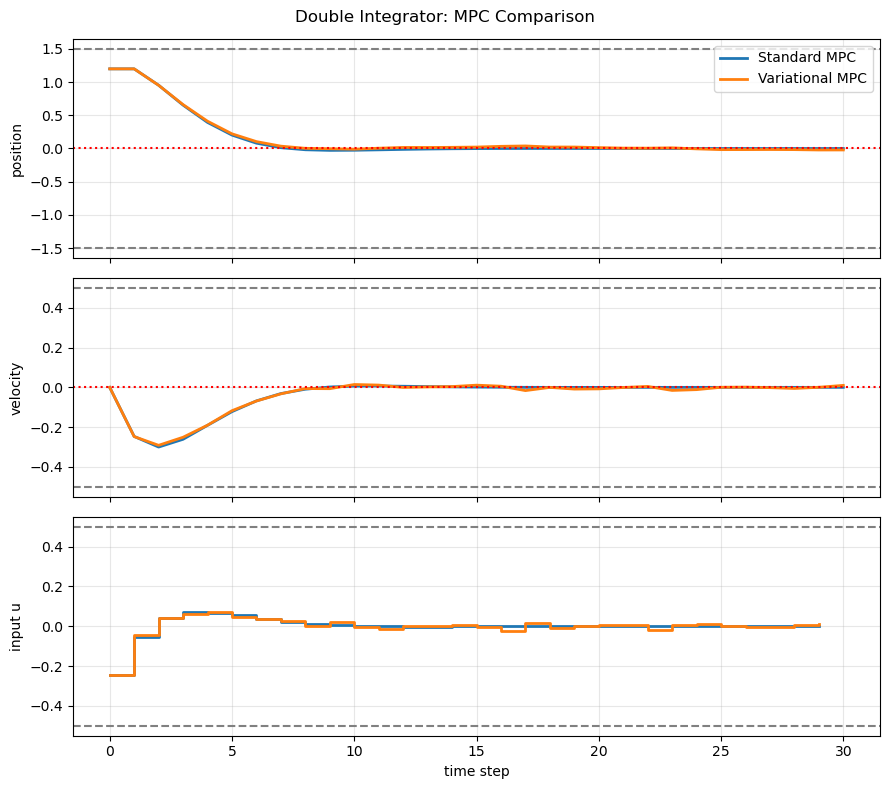

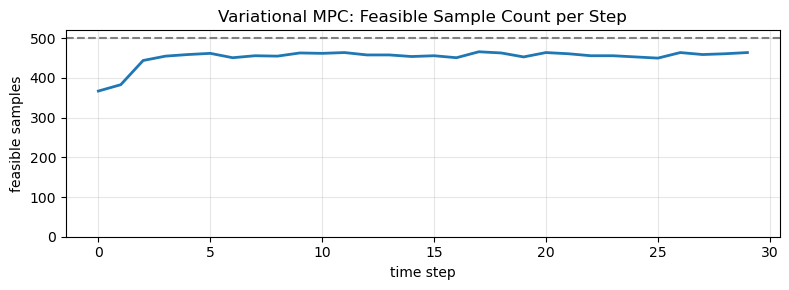

In [2]:


import vempc.examples.double_integrator as di
from vempc.examples.double_integrator import A, B, Q, R, Qf, Gx, hx, Gu, hu
from vempc.core.mpc import MPCProblem, simulate, trajectory_cost, max_constraint_violation
from vempc.core.constraints import ConstraintPenalty
from vempc.core.variational import VariationalMPC
from vempc.solvers.qpMPC import (
    make_standard_qp_solver, solve_standard_mpc,
    chebyshev_relu_coeffs, eval_relu_poly,
)

# %% Problem setup
N       = 10
K       = 500
T_steps = 30
x0      = np.array([1.2, 0.0])

mpc = MPCProblem(A, B, Q, R, Qf, N)
G, h_of_x0 = mpc.build_constraint_matrices(Gx, hx, Gu, hu)
p = G.shape[0]   # number of constraints

# %% Variational parameters
lambda_param = 1.0
sigma_0      = 5.0
Sigma_0      = sigma_0**2 * np.eye(mpc.Nm)

# Polynomial surrogate parameters (mirrors encrypted protocol)
cheb_order = 10
cheb_bound = 6.0          # B_ell: approximation domain [-B_ell, B_ell]
eta        = 1.0          # penalty sharpness
tau_s      = p * float(eval_relu_poly(0.0,
                 chebyshev_relu_coeffs(cheb_order, cheb_bound), cheb_bound))
                          # Corollary 1 threshold: p * h_ell(0)

cheb_coeffs = chebyshev_relu_coeffs(cheb_order, cheb_bound)

print(f"p       = {p}")
print(f"tau_s   = {tau_s:.6f}")
print(f"cheb_bound = {cheb_bound}")

# %% Variational setup
penalty     = ConstraintPenalty(G, h_of_x0, mode='indicator')  # for accept_num tracking
variational = VariationalMPC(mpc, penalty, lambda_param=lambda_param, Sigma_0=Sigma_0)

# %% QP baseline
prob, U_var, q_par, h_par = make_standard_qp_solver(mpc.H, G)

def qp_controller(x, U_warm):
    u0, Useq = solve_standard_mpc(
        x, S=mpc.S, h_of_x0=h_of_x0, m_in=mpc.m,
        prob=prob, U_var=U_var, q_par=q_par, h_par=h_par,
        warm_start_U=U_warm,
    )
    return u0, Useq, {}

# %% Variational controller (polynomial surrogate -- mirrors encrypted protocol)
def variational_controller(x, U_warm):
    U_samples = variational.sample_kappa_tilde(x, K=K)

    # Polynomial surrogate weights (same computation as cloud + client in Algorithm 2)
    residuals = penalty.constraint_residual(U_samples, x)       # g^(i), shape (K, p)
    h_l       = eval_relu_poly(residuals, cheb_coeffs, cheb_bound)  # h_ell(g^(i)_j)
    s_l       = np.sum(h_l, axis=1)                             # s_ell^(i), shape (K,)
    s_bar     = np.maximum(s_l - tau_s, 0.0)                    # thresholded score
    log_w     = -eta * s_bar
    log_w    -= log_w.max()
    w         = np.exp(log_w)
    w        /= w.sum()

    U_hat  = (U_samples * w[:, None]).sum(axis=0)
    u0     = U_hat[:mpc.m]

    # Track true feasibility count separately for diagnostics
    accept_num = int(np.sum(penalty.is_feasible(U_samples, x)))
    info = {"accept_num": accept_num}
    return u0, U_hat, info

# %% Run simulations
xs_qp,  us_qp,  _,        t_qp  = simulate("QP",          x0, qp_controller,          A=A, B=B, T_steps=T_steps)
xs_var, us_var, info_var, t_var  = simulate("Variational", x0, variational_controller, A=A, B=B, T_steps=T_steps)

# %% Costs and violations
cost_qp  = trajectory_cost(xs_qp,  us_qp,  Q=Q, R=R, Qf=Qf)
cost_var = trajectory_cost(xs_var, us_var, Q=Q, R=R, Qf=Qf)

vx_qp,  vu_qp  = max_constraint_violation(xs_qp,  us_qp,  Gx=Gx, hx=hx, Gu=Gu, hu=hu)
vx_var, vu_var = max_constraint_violation(xs_var, us_var, Gx=Gx, hx=hx, Gu=Gu, hu=hu)

print(f"{'':20s} {'QP':>10s} {'Variational':>12s}")
print(f"{'Trajectory cost':20s} {cost_qp:>10.3f} {cost_var:>12.3f}")
print(f"{'Max state viol.':20s} {vx_qp:>10.4f} {vx_var:>12.4f}")
print(f"{'Max input viol.':20s} {vu_qp:>10.4f} {vu_var:>12.4f}")
print(f"{'Solve time (s)':20s} {t_qp:>10.3f} {t_var:>12.3f}")

# %% Plot: trajectories
t_axis  = np.arange(T_steps + 1)
tu_axis = np.arange(T_steps)

labels  = ["Standard MPC", "Variational MPC"]
xs_list = [xs_qp,  xs_var]
us_list = [us_qp,  us_var]
colors  = ["tab:blue", "tab:orange"]

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

for xs, lbl, col in zip(xs_list, labels, colors):
    axes[0].plot(t_axis, xs[:, 0], label=lbl, color=col, linewidth=2.0)
axes[0].axhline(0,         color="red",  linestyle=":",  linewidth=1.5)
axes[0].axhline( di.p_max, color="gray", linestyle="--", linewidth=1.5)
axes[0].axhline(-di.p_max, color="gray", linestyle="--", linewidth=1.5)
axes[0].set_ylabel("position")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for xs, lbl, col in zip(xs_list, labels, colors):
    axes[1].plot(t_axis, xs[:, 1], label=lbl, color=col, linewidth=2.0)
axes[1].axhline(0,         color="red",  linestyle=":",  linewidth=1.5)
axes[1].axhline( di.v_max, color="gray", linestyle="--", linewidth=1.5)
axes[1].axhline(-di.v_max, color="gray", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("velocity")
axes[1].grid(True, alpha=0.3)

for us, lbl, col in zip(us_list, labels, colors):
    axes[2].step(tu_axis, us[:, 0], where="post", label=lbl, color=col, linewidth=2.0)
axes[2].axhline( di.u_max, color="gray", linestyle="--", linewidth=1.5)
axes[2].axhline(-di.u_max, color="gray", linestyle="--", linewidth=1.5)
axes[2].set_ylabel("input u")
axes[2].set_xlabel("time step")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Double Integrator: MPC Comparison")
plt.tight_layout()
plt.show()

# %% Plot: feasible sample count
accept_series = np.array([d["accept_num"] for d in info_var])

plt.figure(figsize=(8, 3))
plt.plot(np.arange(T_steps), accept_series, linewidth=2.0)
plt.axhline(K, color="gray", linestyle="--", linewidth=1.5)
plt.ylabel("feasible samples")
plt.xlabel("time step")
plt.ylim(0, K + 20)
plt.title("Variational MPC: Feasible Sample Count per Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()